<a href="https://colab.research.google.com/github/user-sanchita/Netflix-Content-Analysis-Visualization/blob/main/IBMProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

⏳ Downloading dataset from Kaggle...
Using Colab cache for faster access to the 'netflix-shows' dataset.
✅ Dataset downloaded to: /kaggle/input/netflix-shows

✅ Dataset Loaded Successfully!
Data Shape: 8807 rows, 12 columns



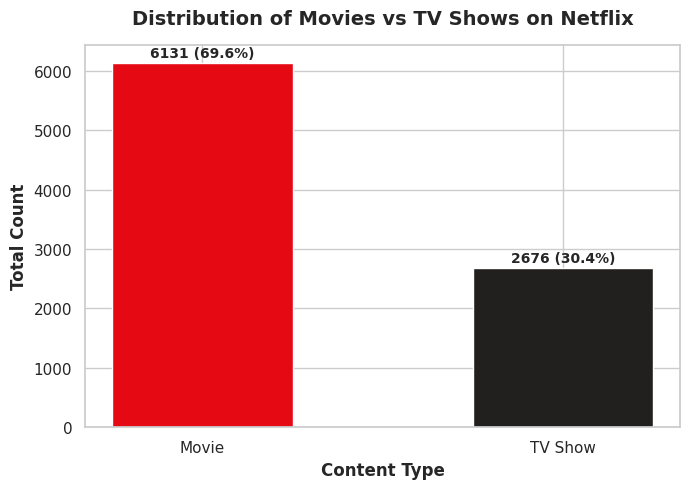

/tmp/ipykernel_4315/2573459411.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')


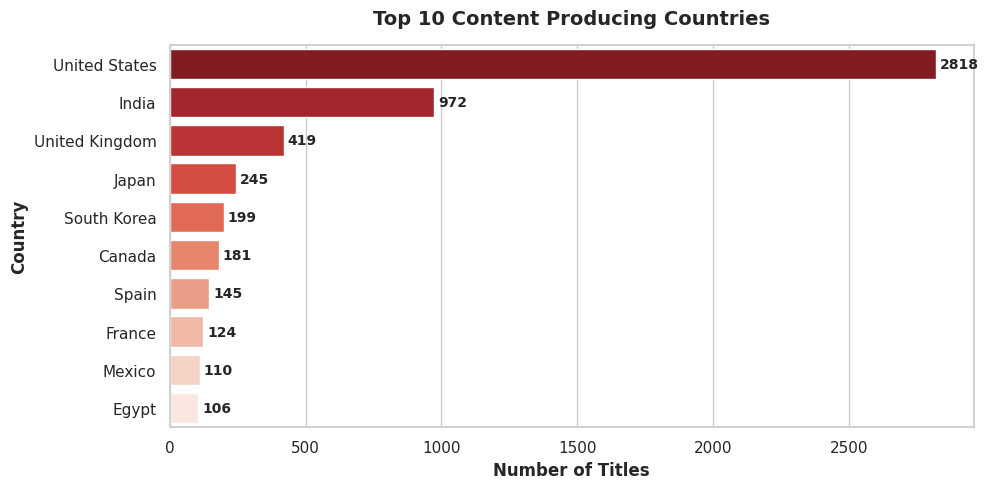

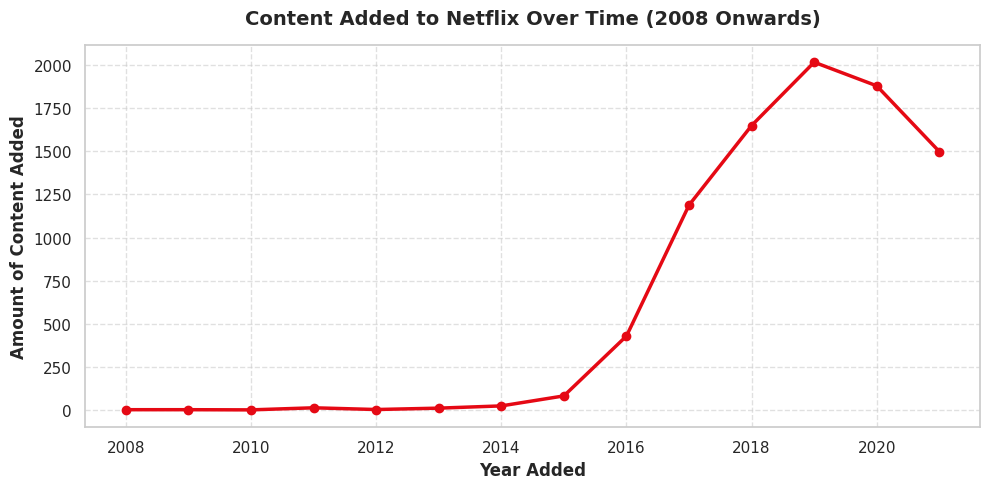

/tmp/ipykernel_4315/2573459411.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ratings.index, y=top_ratings.values, palette='mako')


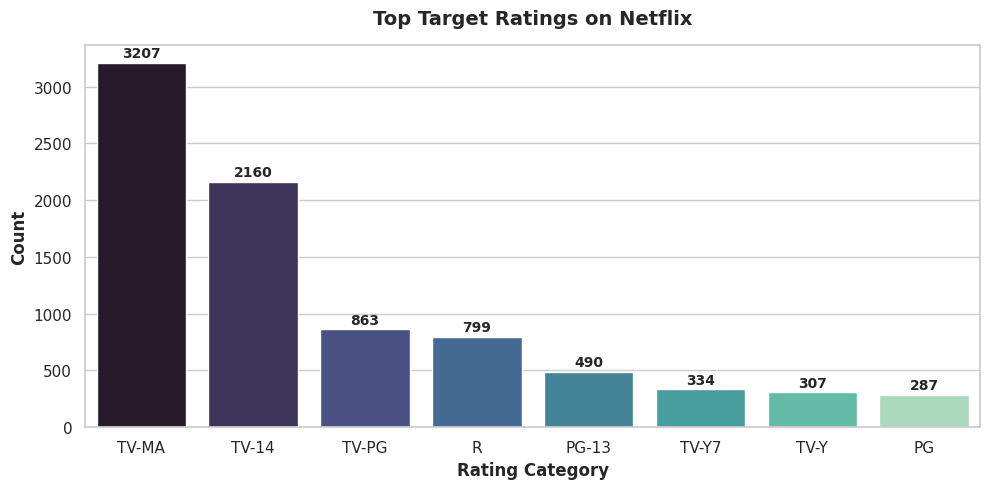

/tmp/ipykernel_4315/2573459411.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genres.values, y=genres.index, palette='flare')


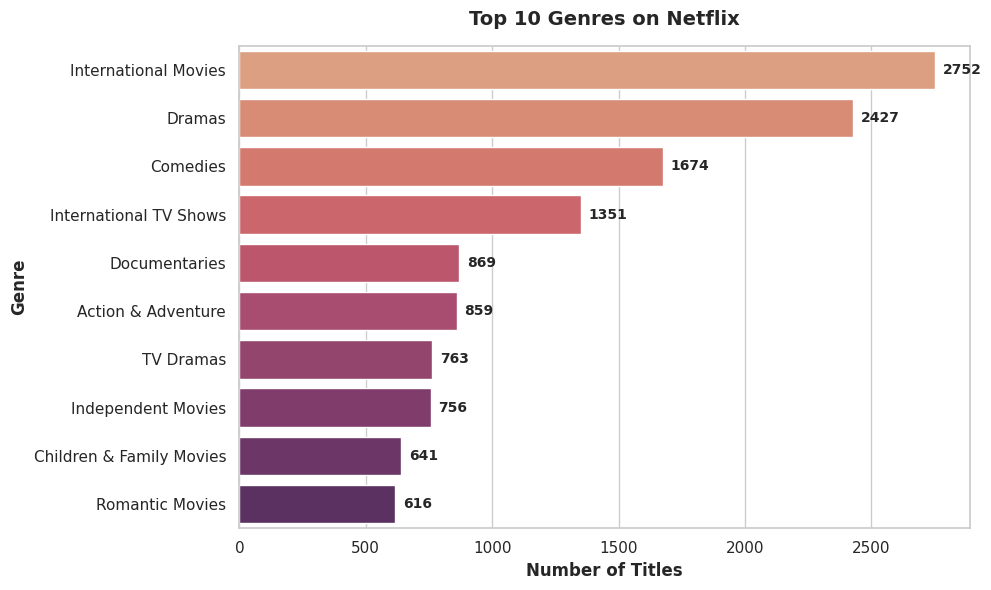

📌 KEY FINDINGS SUMMARY FOR YOUR PRESENTATION
• Total Content Analyzed: 8807 titles
• Content Ratio: 6131 Movies (69.6%) vs 2676 TV Shows (30.4%)
• Top Content Creator Country: United States (2818 titles)
• Most Common Rating: TV-MA (3207 titles)
• Most Popular Genre: International Movies (2752 titles)


In [2]:
# =========================================================
# Project: Netflix Content Analysis & Visualization (EDA)
# Course Showcase: Data Visualization with Python
# =========================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Seaborn Global Theme Setup
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

# ---------------------------------------------------------
# STEP 1: Automatic Dataset Download & Load (via Kagglehub)
# ---------------------------------------------------------
print("⏳ Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("shivamb/netflix-shows")
print(f"✅ Dataset downloaded to: {path}\n")

# Locate CSV file path and load into Pandas DataFrame
csv_file_path = os.path.join(path, "netflix_titles.csv")
df = pd.read_csv(csv_file_path)

print("✅ Dataset Loaded Successfully!")
print(f"Data Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# ---------------------------------------------------------
# STEP 2: Data Cleaning & Preprocessing
# ---------------------------------------------------------
# Formatting 'date_added' to datetime and extracting year
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year

# ---------------------------------------------------------
# STEP 3: Data Visualizations (5 Key Insights)
# ---------------------------------------------------------

# 1. Content Type Breakdown (Movies vs TV Shows)
plt.figure(figsize=(7, 5))
type_counts = df['type'].value_counts()
colors = ['#E50914', '#221F1F'] # Netflix Theme Colors

plt.bar(type_counts.index, type_counts.values, color=colors, width=0.5)
plt.title('Distribution of Movies vs TV Shows on Netflix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Content Type', fontweight='bold')
plt.ylabel('Total Count', fontweight='bold')

for i, value in enumerate(type_counts.values):
    plt.text(i, value + 100, f"{value} ({round(value/len(df)*100, 1)}%)", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


# 2. Top 10 Countries Producing Content
plt.figure(figsize=(10, 5))
top_countries = df['country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')
plt.title('Top 10 Content Producing Countries', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Titles', fontweight='bold')
plt.ylabel('Country', fontweight='bold')

for index, value in enumerate(top_countries.values):
    plt.text(value + 15, index, str(value), va='center', fontweight='bold')

plt.tight_layout()
plt.show()


# 3. Content Addition Trend Over Years (2008 - Present)
plt.figure(figsize=(10, 5))
yearly_content = df['year_added'].value_counts().sort_index()
yearly_content = yearly_content[yearly_content.index >= 2008]

plt.plot(yearly_content.index, yearly_content.values, marker='o', color='#E50914', linewidth=2.5)
plt.title('Content Added to Netflix Over Time (2008 Onwards)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year Added', fontweight='bold')
plt.ylabel('Amount of Content Added', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# 4. Target Ratings Breakdown
plt.figure(figsize=(10, 5))
top_ratings = df['rating'].value_counts().head(8)

sns.barplot(x=top_ratings.index, y=top_ratings.values, palette='mako')
plt.title('Top Target Ratings on Netflix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Rating Category', fontweight='bold')
plt.ylabel('Count', fontweight='bold')

for i, value in enumerate(top_ratings.values):
    plt.text(i, value + 50, str(value), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


# 5. Top 10 Popular Genres
plt.figure(figsize=(10, 6))
genres = df['listed_in'].str.split(', ').explode().value_counts().head(10)

sns.barplot(x=genres.values, y=genres.index, palette='flare')
plt.title('Top 10 Genres on Netflix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Titles', fontweight='bold')
plt.ylabel('Genre', fontweight='bold')

for index, value in enumerate(genres.values):
    plt.text(value + 30, index, str(value), va='center', fontweight='bold')

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# STEP 4: Key Insights Printout (For Presentation Speech)
# ---------------------------------------------------------
print("="*60)
print("📌 KEY FINDINGS SUMMARY FOR YOUR PRESENTATION")
print("="*60)
print(f"• Total Content Analyzed: {len(df)} titles")
print(f"• Content Ratio: {type_counts.get('Movie', 0)} Movies ({round(type_counts.get('Movie', 0)/len(df)*100, 1)}%) vs {type_counts.get('TV Show', 0)} TV Shows ({round(type_counts.get('TV Show', 0)/len(df)*100, 1)}%)")
print(f"• Top Content Creator Country: {top_countries.index[0]} ({top_countries.values[0]} titles)")
print(f"• Most Common Rating: {top_ratings.index[0]} ({top_ratings.values[0]} titles)")
print(f"• Most Popular Genre: {genres.index[0]} ({genres.values[0]} titles)")
print("="*60)